# Task 1: Movie Genre Classification
**CodSoft ML Internship**

Goal: Predict the genre of a movie based on its plot summary using TF-IDF + classifiers.

## Step 1: Install & Import Libraries

In [3]:
# Run this cell first to install any missing libraries
!pip install pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

**How to download the dataset:**
1. Go to: https://www.kaggle.com/datasets/hijest/genre-classification-dataset-imdb
2. Click **Download** (you need a free Kaggle account)
3. Extract the zip file
4. You will get files like `train_data.txt` and `test_data.txt`
5. Place them in the **same folder as this notebook**

In [7]:
# The dataset is a .txt file with ':::' as separator
# Format: ID ::: TITLE ::: GENRE ::: DESCRIPTION

train_df = pd.read_csv(
    'train_data.txt',
    sep=' ::: ',
    engine='python',
    names=['id', 'title', 'genre', 'description']
)

print('Dataset shape:', train_df.shape)
train_df.head()

Dataset shape: (54214, 4)


,id,title,genre,description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


## Step 3: Explore the Data

In [9]:
# Check for missing values
print('Missing values:')
print(train_df.isnull().sum())

print('\nNumber of unique genres:', train_df['genre'].nunique())
print('\nGenre distribution:')
print(train_df['genre'].value_counts())

Missing values:
id             0
title          0
genre          0
description    0
dtype: int64

Number of unique genres: 27

Genre distribution:
genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64


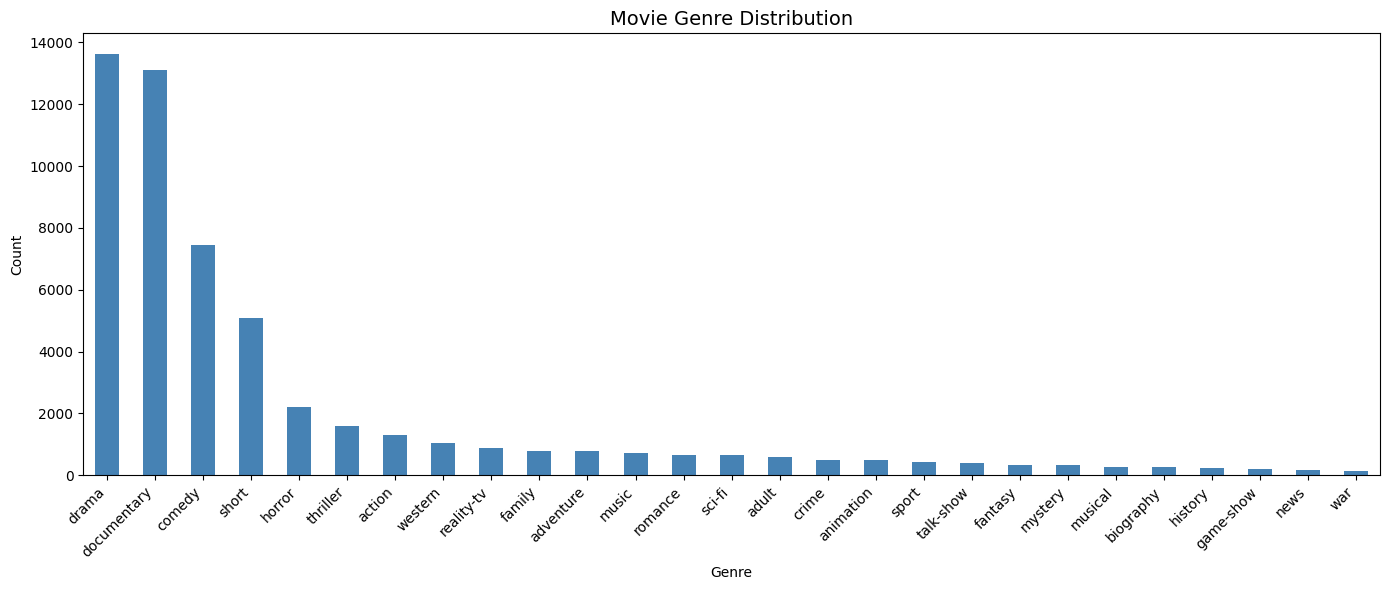

Chart saved!


In [11]:
# Visualize genre distribution
plt.figure(figsize=(14, 6))
train_df['genre'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Movie Genre Distribution', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()
print('Chart saved!')

## Step 4: Preprocess the Data

In [13]:
# Drop rows with missing values
train_df.dropna(inplace=True)

# Clean description text (lowercase, strip whitespace)
train_df['description'] = train_df['description'].str.lower().str.strip()

# Encode genre labels
le = LabelEncoder()
train_df['genre_encoded'] = le.fit_transform(train_df['genre'])

print('Classes:', list(le.classes_))
print('\nSample after encoding:')
train_df[['title', 'genre', 'genre_encoded']].head()

Classes: ['action', 'adult', 'adventure', 'animation', 'biography', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'game-show', 'history', 'horror', 'music', 'musical', 'mystery', 'news', 'reality-tv', 'romance', 'sci-fi', 'short', 'sport', 'talk-show', 'thriller', 'war', 'western']

Sample after encoding:


,title,genre,genre_encoded
0,Oscar et la dame rose (2009),drama,8
1,Cupid (1997),thriller,24
2,"Young, Wild and Wonderful (1980)",adult,1
3,The Secret Sin (1915),drama,8
4,The Unrecovered (2007),drama,8


## Step 5: TF-IDF Vectorization

In [15]:
# Split features and target
X = train_df['description']
y = train_df['genre_encoded']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),   # unigrams + bigrams
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('Train shape:', X_train_tfidf.shape)
print('Test shape: ', X_test_tfidf.shape)

Train shape: (43371, 10000)
Test shape:  (10843, 10000)


## Step 6: Train & Compare 3 Models

In [17]:
models = {
    'Naive Bayes':        MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5),
    'Linear SVM':          LinearSVC(max_iter=1000, C=1)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f'{name}: Accuracy = {acc:.4f}')

Naive Bayes: Accuracy = 0.5193
Logistic Regression: Accuracy = 0.5790
Linear SVM: Accuracy = 0.5652


In [18]:
# Best model detailed report
best_model_name = max(results, key=results.get)
print(f'Best Model: {best_model_name} ({results[best_model_name]:.4f})\n')

best_model = models[best_model_name]
best_preds = best_model.predict(X_test_tfidf)

print(classification_report(
    y_test, best_preds,
    target_names=le.classes_
))

Best Model: Logistic Regression (0.5790)

              precision    recall  f1-score   support

      action       0.51      0.37      0.43       263
       adult       0.75      0.41      0.53       118
   adventure       0.45      0.19      0.27       155
   animation       0.37      0.16      0.22       100
   biography       0.00      0.00      0.00        53
      comedy       0.52      0.59      0.56      1490
       crime       0.22      0.05      0.08       101
 documentary       0.69      0.81      0.75      2619
       drama       0.56      0.71      0.63      2723
      family       0.39      0.16      0.23       157
     fantasy       0.11      0.02      0.03        65
   game-show       0.91      0.54      0.68        39
     history       0.80      0.08      0.15        49
      horror       0.66      0.60      0.63       441
       music       0.62      0.47      0.53       146
     musical       0.17      0.04      0.06        55
     mystery       0.43      0.05      

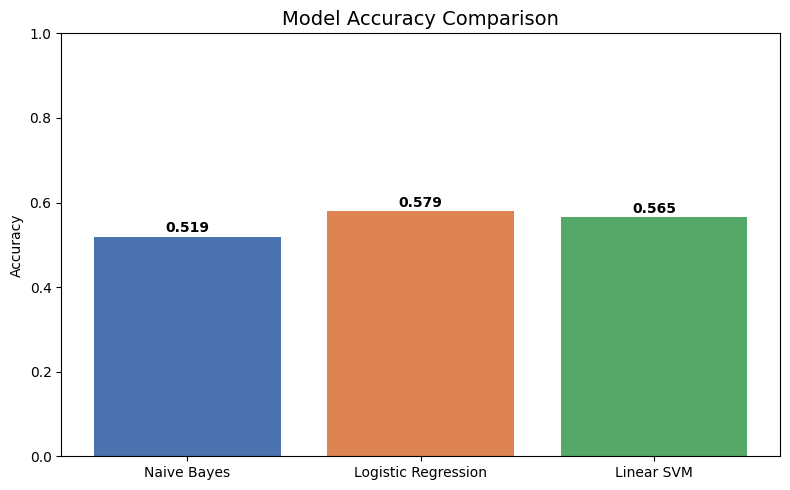

In [21]:
# Accuracy comparison bar chart
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## Step 7: Predict on New Input

In [23]:
def predict_genre(plot_summary):
    vec = tfidf.transform([plot_summary.lower()])
    pred = best_model.predict(vec)[0]
    genre = le.inverse_transform([pred])[0]
    return genre

# Test with a custom plot
sample = "A detective investigates a series of brutal murders in a small town and uncovers a dark conspiracy."
print('Plot   :', sample)
print('Predicted Genre:', predict_genre(sample))

Plot   : A detective investigates a series of brutal murders in a small town and uncovers a dark conspiracy.
Predicted Genre: thriller


## ✅ Task 1 Complete!
- Loaded IMDB genre dataset
- Applied TF-IDF vectorization
- Trained Naive Bayes, Logistic Regression, Linear SVM
- Compared models and selected best performer
- Built a prediction function for new movie plots